# PSE-823: Advanced Process Dynamics and Control
## Lecture 13 -- Multivariable Control: Interaction, RGA, Decoupling
### (Coughanowr & LeBlanc, Ch. 23; Cecil, Ch. 7 and Sec. 8.1)

Date: __________

## Agenda

**Part A** -- Interacting systems: the transfer-function matrix
(Ch. 23, Sec. 23.1)

**Part B** -- How much interaction? Relative gains and pairing
(Cecil, Sec. 7.3-7.5)

**Part C** -- Decoupling: cross-controllers and decouplers
(Ch. 23; Cecil, Sec. 8.1)

**Part D** -- Stability of a multiloop system (Sec. 23.2)

### Setup (run once)

- The standard imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import control as ct
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
plt.rcParams.update({"font.size": 15})

## Part A
### Interacting Systems

(Coughanowr & LeBlanc, Ch. 23, Sec. 23.1)
<!-- source: coughanowr-ch23 -->

### Introduce -- two inputs, two outputs (Fig. 23-2, Fig. 23-8)

- Two interacting tanks; flows $m_1$, $m_2$ in; levels $c_1$, $c_2$
  out. Each input moves **both** levels.
- Ex. 23.1: $A_1 = 1$, $A_2 = \tfrac12$, $R_1 = \tfrac12$, $R_2 = 2$,
  $R_3 = 1$:

$$\dot c_1 = m_1 - 3c_1 + 2c_2,\qquad \dot c_2 = 2m_2 + 4c_1 - 5c_2$$

- Two loops ($m_1 \to c_1$, $m_2 \to c_2$): a set-point change in one
  disturbs the other through $G_{21}$, $G_{12}$.

### Derive 1/2 -- the transfer-function matrix (Eq. 23.21)

$\dot{\mathbf c} = A\mathbf c + B\mathbf m$; transform with zero initial state:

$$\mathbf C(s) = (sI - A)^{-1}B\,\mathbf M(s) = G_p\mathbf M,\quad
G_p = \frac{1}{(s+1)(s+7)}\begin{bmatrix} s + 5 & 4\\ 4 & 2(s + 3)
\end{bmatrix}$$

### Derive 2/2 -- the closed loop in matrix form (Eq. 23.11)

$\mathbf M = G_c\mathbf E$, $\mathbf E = \mathbf R - \mathbf C$ (valves, sensors = $I$):

$$\mathbf C = (I + G_pG_c)^{-1}G_pG_c\,\mathbf R$$

The scalar $G/(1 + G)$, with matrices. Order matters:
$G_pG_c \ne G_cG_p$.

### Code 1/3 -- $G_p$ with sympy

- Mirrors Derive 1/2: one matrix inverse

In [2]:
s = sp.symbols("s")
A = sp.Matrix([[-3, 2], [4, -5]])
B = sp.diag(1, 2)
Gp = sp.simplify((s * sp.eye(2) - A).inv() * B)
Gp.applyfunc(sp.factor)

Matrix([
[(s + 5)/((s + 1)*(s + 7)),         4/((s + 1)*(s + 7))],
[      4/((s + 1)*(s + 7)), 2*(s + 3)/((s + 1)*(s + 7))]])

**Code walkthrough.** `sp.Matrix` and `sp.diag` build A and B (Eqs. 23.18-23.19);
`.inv()` inverts sI - A symbolically and `*` is matrix multiplication
for sympy matrices. `applyfunc(sp.factor)` factors each element and shows it over
(s + 1)(s + 7): (s + 5), 4, 4 and 2(s + 3) -- Eq. 23.21. The diagonal
elements have a numerator zero (finite initial slope); the
off-diagonal ones do not (zero initial slope, Fig. 23-9).

### Code 2/3 -- the same model, numerically

- `ct.ss` with two inputs and two outputs; steady-state gains

In [3]:
An, Bn = np.array(A, dtype=float), np.array(B, dtype=float)
plant = ct.ss(An, Bn, np.eye(2), 0)
K = -np.linalg.inv(An) @ Bn                  # Gp(0)
print(np.round(K, 3)); print(np.round(ct.dcgain(plant), 3))

[[0.714 0.571]
 [0.571 0.857]]
[[0.714 0.571]
 [0.571 0.857]]


**Code walkthrough.** `np.array(..., dtype=float)` converts the sympy matrices. `ct.ss`
takes A, B, C (here the identity: both levels measured) and D = 0;
a state-space model handles several inputs and outputs directly.
The steady-state gain matrix is Gp(0) = (0 I - A)^(-1) B = -A^(-1) B:
[[0.714 0.571] [0.571 0.857]] (5/7, 4/7, 4/7, 6/7). `ct.dcgain`
agrees. Every gain is positive: each flow raises both levels.

### Code 3/3 -- two P loops, step in $r_1$ (Fig. 23-14a)

- Mirrors Derive 2/2 for $G_c = \mathrm{diag}(4, 4)$
- With P control, $\mathbf m = K_c(\mathbf r - \mathbf c)$ folds into $A$

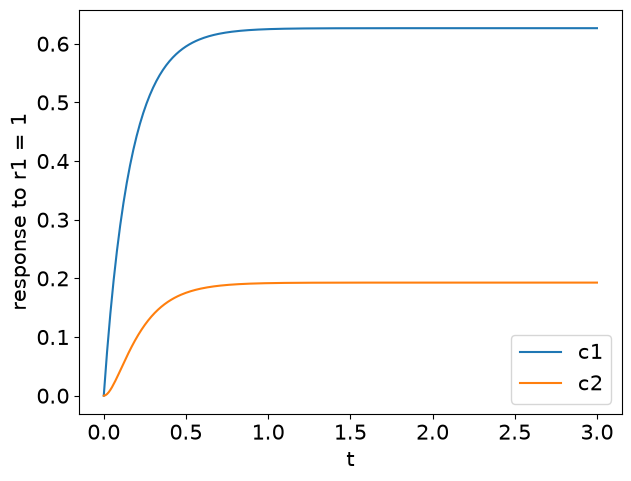

In [4]:
Kc = np.diag([4.0, 4.0])
loop = ct.ss(An - Bn @ Kc, Bn @ Kc, np.eye(2), 0)
t = np.linspace(0, 3, 301)
y = ct.step_response(loop, t).outputs        # [output, input, time]
fig, ax = plt.subplots(figsize=(7, 5.25))
ax.plot(t, y[0, 0], label="c1"); ax.plot(t, y[1, 0], label="c2")
ax.set(xlabel="t", ylabel="response to r1 = 1"); ax.legend()
plt.show()

**Code walkthrough.** Substituting m = Kc (r - c) into dc/dt = A c + B m gives
dc/dt = (A - B Kc) c + B Kc r: a new state-space model with input r.
`step_response` of a 2 x 2 model returns outputs indexed
[output, input, time]; `y[1, 0]` is c2's response to a step in r1.
c1 rises to 0.627 (P offset); c2, which no one asked to change,
rises to 0.193: interaction.

### Your Turn (6 min)

1. By hand: from Eq. 23.21, what is $G_{22}(0)$? What does it mean?
2. Read the code: what is the shape of `y`, and what is `y[0, 1, -1]`?

```python
y = ct.step_response(loop, t).outputs
```

(1) 2(3)/7 = 6/7: a unit step in m2 raises c2 by 0.857 at steady
state with m1 fixed.
(2) (2, 2, 301). y[0, 1, -1] is the final value of c1 for a unit step
in r2: the interaction in the other direction.

### Check -- cold-call

Why can't we just tune loop 1 as if loop 2 did not exist?

Because when loop 2 is on automatic it moves m2 in response to c2,
and m2 also changes c1. The process loop 1 sees depends on whether
loop 2 is open or closed -- which Part B quantifies.

## Part B
### Relative Gains and Pairing

(Cecil, Ch. 7, Sec. 7.3-7.5)
<!-- source: cecil-ch07 -->

### Introduce -- one sensitivity, two values (Cecil, Fig. 7.7)

- Tune loop 1 with loop 2 on **manual**: process gain
  $K_{11} = \partial C_1/\partial M_1|_{M_2}$.
- Switch loop 2 to **automatic**: now
  $K'_{11} = \partial C_1/\partial M_1|_{C_2}$.
- **Relative gain** $\lambda_{11} = K_{11}/K'_{11}$: 1 means no
  interaction; 0.8-1.2 rarely a problem; 0.5-2 needs dynamic separation;
  negative: the loop changes direction.

### Derive 1/2 -- $K'_{11}$ for a 2 x 2 process

Hold $\Delta C_2 = 0$ in $\Delta\mathbf C = K\Delta\mathbf M$:

$0 = K_{21}\Delta M_1 + K_{22}\Delta M_2 \Rightarrow \Delta M_2 =
-\frac{K_{21}}{K_{22}}\Delta M_1$, so
$K'_{11} = K_{11} - \frac{K_{12}K_{21}}{K_{22}}$ and

$$\lambda_{11} = \frac{K_{11}K_{22}}{K_{11}K_{22} - K_{12}K_{21}}$$

### Derive 2/2 -- the relative gain array (Cecil approach 2)

In general $K'_{ij} = 1/(K^{-1})^T_{ij}$:

$$\Lambda = K \circ (K^{-1})^T$$

($\circ$: element by element.) Rows and columns sum to 1. Pair each
$C_i$ with the $M_j$ whose $\lambda_{ij}$ is positive and closest to 1.

### Code 1/3 -- the RGA as a function

- Mirrors Derive 2/2: `*` on numpy arrays is element by element

In [5]:
def rga(K):
    return K * np.linalg.inv(K).T
L = rga(K)
print(np.round(L, 3), "row sums:", L.sum(axis=1))

[[ 2.143 -1.143]
 [-1.143  2.143]] row sums: [1. 1.]


**Code walkthrough.** For numpy arrays `*` multiplies element by element, `@` is the matrix
product, and `.T` transposes. For Ex. 23.1: lambda_11 = 2.143 and
lambda_12 = -1.143, so pair c1-m1 and c2-m2 (the positive pair), but
with strong interaction: closing loop 2 cuts loop 1's gain to
1/2.14 of its open value. Row sums are 1, as required.

### Code 2/3 -- check $K'_{11}$ by a "process test"

- Step $m_1$ with loop 2 on integral control; read $c_1$ (Cecil's Fig. 7.13 test)

In [6]:
def test(t, z):                          # z = [c1, c2, integral of c2]
    c, I = z[:2], z[2]
    m = np.array([1.0, -5.0 * I])        # m1 stepped; I-control on c2
    return np.concatenate([An @ c + Bn @ m, [c[1]]])
sol = solve_ivp(test, (0, 20), np.zeros(3), max_step=0.01)
c1, c2 = sol.y[0, -1], sol.y[1, -1]
print(f"c2 = {c2:.1e}, K'11 = c1 = {c1:.4f}, "
      f"lambda11 = {K[0, 0] / c1:.3f}")

c2 = 7.2e-10, K'11 = c1 = 0.3333, lambda11 = 2.143


**Code walkthrough.** The process test, simulated: loop 1 on manual with m1 stepped by 1;
loop 2 on integral-only control (m2 = -5 times the integral of c2),
which drives c2 back to zero. The extra state is that integral. At the
end c2 is about 1e-9 and c1 = 0.3333: K'11 = 1/3, as Derive 1/2 gives
(5/7 - (4/7)(4/7)/(6/7)). lambda11 = (5/7)/(1/3) = 2.143.

### Build on it -- Cecil's purified water process

- Gains from Cecil's steady-state model at zero user flow
- $C_1$ recirculation pressure, $C_2$ recirculation flow; $M_1$ valve, $M_2$ pump speed

In [ ]:
Kw = np.array([[-0.546, 0.0444],             # psig/%, psig/rpm
               [1.160, 0.0109]])             # gpm/%,  gpm/rpm
print(np.round(rga(Kw), 2))

**Code walkthrough.** Cecil's Sec. 7.4 sensitivities (units differ by column, which the RGA
does not mind: it is dimensionless). Prints [[0.1 0.9] [0.9 0.1]]:
lambda_11 = 0.10, Cecil's value. Pairing pressure with the valve and
flow with the pump speed is the poor pairing; the RGA says pair the
pressure with the pump speed (0.90) and the flow with the valve.

### Your Turn (6 min)

1. By hand: $K = \begin{bmatrix}2 & 1\\ 1 & 2\end{bmatrix}$. Find
   $\lambda_{11}$ and the full RGA.
2. Read the code: what does it print?

```python
print(rga(np.diag([3.0, 0.5])))
```

(1) lambda11 = 4/(4 - 1) = 1.333; RGA [[1.333, -0.333], [-0.333,
1.333]].
(2) [[1. 0.] [0. 1.]] (with -0. possible): a diagonal process has no
interaction.

### Check -- poll

$\lambda_{11} = -0.6$ for your proposed pairing. Loop 1 is tuned with
loop 2 on manual, then loop 2 is switched to automatic. Loop 1:

**A)** becomes slower  **B)** becomes faster  **C)** acts in the wrong
direction

C. A negative relative gain means K11 and K'11 have opposite signs:
the controller's action is correct with loop 2 open and wrong with it
closed -- positive feedback, instability. Choose another pairing.

## Part C
### Decoupling

(Coughanowr & LeBlanc, Ch. 23; Cecil, Ch. 8, Sec. 8.1)
<!-- source: coughanowr-ch23 -->

### Introduce -- cancel the interaction (Fig. 23-5; Cecil Fig. 8.1)

- Add **cross-controllers** $G_{c12}$, $G_{c21}$: each loop's error
  also moves the other input, to cancel its side effect.
- Noninteracting if $G_o = G_pG_c$ is diagonal (Eq. 23.13).
- Cecil: a steady-state **decoupler** $D$ between controllers and
  process, $\mathbf m = D\mathbf x$ with $KD = I$, so $D = K^{-1}$.

### Derive 1/2 -- the cross-controllers (Eqs. 23.14-23.15)

Set the off-diagonal elements of $G_pG_c$ to zero:

$$G_{c12} = -\frac{G_{12}G_{c22}}{G_{11}},\quad
G_{c21} = -\frac{G_{21}G_{c11}}{G_{22}}$$

Ex. 23.2, $G_{c11} = K_1$, $G_{c22} = K_2$:
$G_{c12} = \frac{-4K_2}{s + 5}$, $G_{c21} = \frac{-2K_1}{s + 3}$.

### Derive 2/2 -- the decoupled loops (Eq. 23.25)

Substitute back:

$G_o = \mathrm{diag}\left(\frac{K_1}{s + 3}, \frac{2K_2}{s + 5}\right)$,
so $\frac{C_1}{R_1} = \frac{K_1}{s + 3 + K_1}$ and $c_2$ does not
move. With $K_1 = 4$: final $c_1 = 4/7 = 0.571$.

### Code 1/3 -- Eqs. 23.14-23.15 with sympy

- Mirrors Derive 1/2; then check that $G_pG_c$ is diagonal

In [8]:
K1, K2 = sp.symbols("K1 K2", positive=True)
Gc12 = sp.simplify(-Gp[0, 1] * K2 / Gp[0, 0])
Gc21 = sp.simplify(-Gp[1, 0] * K1 / Gp[1, 1])
Go = sp.simplify(Gp * sp.Matrix([[K1, Gc12], [Gc21, K2]]))
print(Gc12, "|", Gc21); Go

-4*K2/(s + 5) | -2*K1/(s + 3)


Matrix([
[K1/(s + 3),            0],
[         0, 2*K2/(s + 5)]])

**Code walkthrough.** Indexing a sympy matrix as `Gp[0, 1]` gives G12 (Python counts from
0). The two formulas give -4K2/(s + 5) and -2K1/(s + 3), Eqs.
23.22-23.23. Multiplying out Gp Gc and simplifying gives a diagonal
matrix: K1/(s + 3) and 2K2/(s + 5), Eq. 23.25. The (s + 1)(s + 7)
poles cancel.

### Code 2/3 -- simulate with the cross-controllers (Fig. 23-14b)

- Each cross-controller is a first-order lag: one extra state each

In [9]:
def decoupled(t, z, r=np.array([1.0, 0.0]), k1=4.0, k2=4.0):
    c, x = z[:2], z[2:]                  # levels, cross-ctrl states
    e = r - c
    m = np.array([k1*e[0] - 4*k2*x[0], k2*e[1] - 2*k1*x[1]])
    return np.concatenate([An @ c + Bn @ m,
                           [-5*x[0] + e[1], -3*x[1] + e[0]]])
sol = solve_ivp(decoupled, (0, 3), np.zeros(4), t_eval=t,
                max_step=0.01)
print(f"final c1 = {sol.y[0, -1]:.4f}, "
      f"max |c2| = {np.abs(sol.y[1]).max():.1e}")

final c1 = 0.5714, max |c2| = 0.0e+00


**Code walkthrough.** -4K2/(s + 5) acting on e2 is realized as dx1/dt = -5 x1 + e2 with
output -4 K2 x1; likewise -2K1/(s + 3) on e1. So m1 = K1 e1 - 4K2 x1
and m2 = K2 e2 - 2K1 x2 (Eqs. 23.2-23.3). Final c1 = 0.5714 = 4/7, and
c2 never leaves zero (the max prints 0.0e+00): perfect decoupling --
with a perfect model.

### Build on it -- Cecil's steady-state decoupler $D = K^{-1}$

- Two P controllers, $\mathbf m = D K_c(\mathbf r - \mathbf c)$

In [ ]:
D = np.linalg.inv(K)
r = np.array([1.0, 0.0])
ss_dec = solve_ivp(lambda t, c: An @ c + Bn @ D @ Kc @ (r - c),
                   (0, 3), np.zeros(2), t_eval=t, max_step=0.01)
print(np.round(D, 2), "final:", np.round(ss_dec.y[:, -1], 3),
      "peak c2:", round(np.abs(ss_dec.y[1]).max(), 3))

**Code walkthrough.** D = K^(-1) = [[3, -2], [-2, 2.5]] makes K D = I: at steady state each
controller output moves only its own variable. Final c1 = 0.8, c2 = 0:
no steady interaction. But c2 swings to 0.33 on the way -- more than
the 0.19 without any decoupler, because D acts instantly while the
process responds with dynamics. A steady-state decoupler fixes the
steady state only (Cecil: add dynamics -- lead-lag -- if needed).

### Your Turn (6 min)

1. By hand: why does the decoupler need an accurate model? What
   happens to $c_2$ if the true $G_{12}$ is 20% larger than assumed?
2. Read the code: what does this print?

```python
print(np.round(K @ np.linalg.inv(K), 3))
```

(1) The cross-controller cancels G12 using the model; a 20% error
leaves 20% of the interaction: c2 moves, less than without decoupling.
(2) [[1. 0.] [0. 1.]] (perhaps -0.): K times its inverse is the
identity -- the steady-state design objective K D = I.

### Check -- think-pair-share

Cecil insists each decoupler output needs its own hand station and
bumpless transfer. Why is "the decoupler as a whole on manual" not
good enough?

Operators must be able to take one valve to manual (e.g. a failed
sensor) while the rest keeps working, without bumps and without the
PID controllers winding up. The implementation issues (manual,
bumpless transfer, output limits) are often harder than the design.

## Part D
### Stability of a Multiloop System

(Coughanowr & LeBlanc, Ch. 23, Sec. 23.2)
<!-- source: coughanowr-ch23 -->

### Introduce -- one characteristic equation for all loops

- $\mathbf C = \dfrac{\mathrm{adj}(I + G_oG_m)\,G_o\mathbf R}
  {|I + G_oG_m|}$ (Eq. 23.28): every element has the same denominator.
- Characteristic equation: $|I + G_oG_m| = 0$ (Eq. 23.32).
- Ex. 23.4: Ex. 23.2 without cross-controllers. Stable for which
  $(K_1, K_2)$?

### Derive 1/1 -- the determinant

$|I + G_pG_c| = (1 + K_1G_{11})(1 + K_2G_{22}) - K_1K_2G_{12}G_{21}$:

Over the common denominator $[(s+1)(s+7)]^2$ the book obtains a
quartic (Eq. 23.34). Factor it: $(s+1)(s+7)$ cancels and

$$s^2 + (8 + K_1 + 2K_2)s + 7 + 5K_1 + 6K_2 + 2K_1K_2 = 0$$

Two states, static controllers: two closed-loop poles.

### Code 1/2 -- the characteristic polynomial

- Mirrors Derive 1/1 with sympy

In [11]:
k1, k2 = sp.symbols("K1 K2")
det = sp.factor(sp.together((sp.eye(2) + Gp * sp.diag(k1, k2)).det()))
num, den = sp.fraction(det)
print("numerator:", sp.Poly(sp.expand(num), s).all_coeffs())
print("denominator:", den)

numerator: [1, K1 + 2*K2 + 8, 2*K1*K2 + 5*K1 + 6*K2 + 7]
denominator: (s + 1)*(s + 7)


**Code walkthrough.** New symbols k1, k2 without `positive=True`, so negative gains are
allowed. `.det()` expands the 2 x 2 determinant; `together` puts it
over one denominator and `factor` cancels common factors; `fraction`
splits numerator and denominator. Numerator coefficients: [1,
K1 + 2K2 + 8, 2K1K2 + 5K1 + 6K2 + 7]; denominator (s + 1)(s + 7).
The closed-loop poles are the numerator's roots.

### Code 2/2 -- the stability region in the $K_1$-$K_2$ plane

- Brute force on a grid with `np.roots`; second order: all coefficients positive

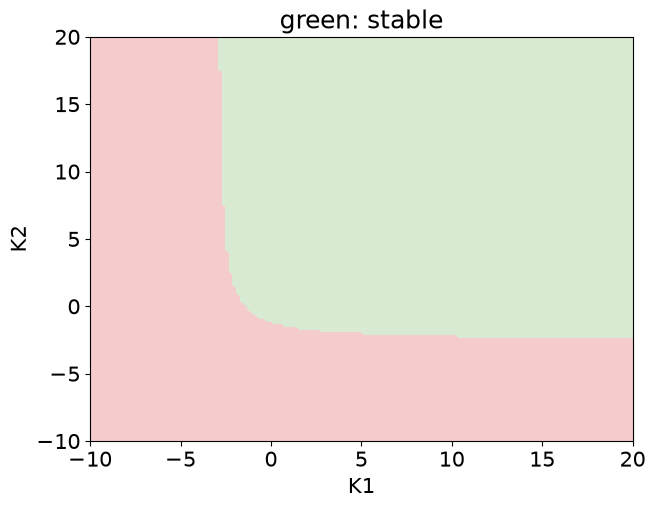

In [12]:
coef = sp.lambdify((k1, k2), sp.Poly(sp.expand(num), s).all_coeffs())
ks = np.linspace(-10, 20, 151)
ok = np.array([[np.all(np.roots(np.array(coef(a, b), float)).real < 0)
                for a in ks] for b in ks])
fig, ax = plt.subplots(figsize=(7, 5.25))
ax.contourf(ks, ks, ok, levels=[-0.5, 0.5, 1.5],
            colors=["#f4cccc", "#d9ead3"])
ax.set(xlabel="K1", ylabel="K2", title="green: stable"); plt.show()

**Code walkthrough.** `sp.lambdify` turns the symbolic coefficient list into a fast Python
function of (K1, K2). For each grid point `np.roots` finds the two
closed-loop poles; `ok` is True where both have negative real parts.
`contourf` with two levels colours stable (green) and unstable (red)
regions. Every positive pair is stable, and so are modestly negative
gains. The boundary is a0 = 0: 7 + 5K1 + 6K2 + 2K1K2 = 0, i.e.
(2K1 + 6)(K2 + 2.5) = 8, a hyperbola with asymptotes K1 = -3 and
K2 = -2.5.

### Your Turn (6 min)

1. By hand: for a second-order polynomial $s^2 + a_1s + a_0$, what are
   the stability conditions? Apply them at $K_1 = K_2 = -2$.
2. Read the code: what does this print?

```python
print(np.all(np.roots([1.0, 2.0, -3.0]).real < 0))
```

(1) a1 > 0 and a0 > 0 (Routh, Lecture 6). At K1 = K2 = -2:
a1 = 8 - 2 - 4 = 2 > 0, a0 = 7 - 10 - 12 + 8 = -7 < 0: unstable.
(2) False: roots 1 and -3; one is in the right half-plane.

### Check -- cold-call

The book stops at "the Routh test can be applied" to the quartic. What
did the factorization buy us, and when would it not be available?

It reduced the problem to a quadratic, whose stability is just two
sign conditions. With dynamic controllers (PI), measurement lags or
dead time, no such cancellation occurs and the characteristic
equation is genuinely of high order: then numerical root finding (or
a simulation) is the practical route.

### Wrap-up

**Derived, then coded:** the transfer-function matrix
$(sI - A)^{-1}B$; the closed loop in matrix form; relative gains and
the RGA (checked by a simulated process test); cross-controllers and a
steady-state decoupler; the multiloop characteristic equation and its
stability region.

**Tools:** `sp.Matrix.inv`, `ct.ss` (MIMO), `np.linalg.inv`,
element-wise `*` versus `@`, `solve_ivp` with controller states,
`sp.lambdify`, `contourf`

**Next:** Ch. 24-25 -- nonlinear systems and the phase plane.